# Estimating the interferometer residual OPD from frequency-modulated phasemeter data

This notebook documents, end to end, how the `het_ifo_opd` package estimates the
**residual optical path-length difference (OPD)** of the FM1 interferometer from
Moku:Pro Phasemeter recordings, and then runs the full FM1 analysis and
discusses the results.

**Contents**

1. [The measurement principle](#principle) — how a laser-frequency modulation encodes the OPD.
2. [The data](#data) — what a Moku:Pro Phasemeter file contains.
3. [Why the *differential* phase](#differential) — common-mode rejection of laser noise.
4. [The estimator](#estimator) — least-squares lock-in, spectral cross-check, and uncertainty.
5. [Worked single-file example](#single) — a clean acquisition, step by step.
6. [Full FM1 analysis](#full) — every acquisition, with the correct modulation frequency per day.
7. [Discussion of results](#discussion).
8. [Conclusions](#conclusions).

In [3]:
%matplotlib inline
import os
import logging

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from het_ifo_opd import OPDConfig, estimate_opd, estimate_opd_dataset, load_phasemeter
from het_ifo_opd.physics import phase_cycles_to_opd
from het_ifo_opd.estimators import lockin_amplitude, single_bin_amplitude
from het_ifo_opd.plotting import plot_diagnostics, plot_dataset_summary
from speckit import compute_spectrum

logging.getLogger("het_ifo_opd").setLevel(logging.WARNING)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Locate the FM1 data directory (works whether the notebook is run from the
# repo root or from notebooks/).
_candidates = ["data/FM1", "../data/FM1"]
FM1_DIR = next((p for p in _candidates if os.path.isdir(p)), "FM1")
print("FM1 directory:", os.path.abspath(FM1_DIR))

# Default physics configuration (matches the FM1 set-up).
cfg = OPDConfig()
print(f"Laser wavelength       : {cfg.laser_wavelength*1e9:.0f} nm "
      f"(carrier {cfg.laser_frequency/1e12:.2f} THz)")
print(f"Actuator transfer fn   : {cfg.actuator_tf/1e6:.0f} MHz/V")
print(f"Modulation amplitude   : {cfg.mod_vpp:.1f} Vpp")
print(f"=> peak freq deviation : {cfg.freq_dev_peak/1e6:.0f} MHz (zero-to-peak)")


FM1 directory: /Users/mdovale/Work-local/het_ifo_opd/data/FM1
Laser wavelength       : 1550 nm (carrier 193.41 THz)
Actuator transfer fn   : 376 MHz/V
Modulation amplitude   : 1.0 Vpp
=> peak freq deviation : 188 MHz (zero-to-peak)


<a id="principle"></a>
## 1. The measurement principle

An interferometer with an optical path-length difference $\mathrm{OPD}$ between
its two arms converts the instantaneous **optical frequency** $\nu(t)$ of the
laser into an interferometric phase

$$
\varphi(t) \;=\; \nu(t)\,\frac{\mathrm{OPD}}{c}\qquad\text{[cycles]} .
$$

(Equivalently $\varphi = \mathrm{OPD}/\lambda$, since $\nu = c/\lambda$.) The
phasemeter reports $\varphi$ directly, in cycles.

If we now **modulate the laser frequency** by a small amount $\delta\nu(t)$ about
its mean $\nu_0$, the phase acquires a corresponding modulation

$$
\delta\varphi(t) \;=\; \frac{\mathrm{OPD}}{c}\,\delta\nu(t),
$$

because $\mathrm{d}\varphi/\mathrm{d}\nu = \mathrm{OPD}/c$. The relation is
**linear**: every Fourier component of $\delta\nu$ maps to the *same* component
of $\delta\varphi$, scaled by the constant $\mathrm{OPD}/c$.

Driving the laser-frequency actuator with a single tone at $f_\mathrm{mod}$,

$$
\delta\nu(t) = \delta\nu_\mathrm{pk}\cos(2\pi f_\mathrm{mod} t),
$$

therefore writes a phase tone of amplitude

$$
A_\varphi = \frac{\mathrm{OPD}}{c}\,\delta\nu_\mathrm{pk}
\qquad\Longrightarrow\qquad
\boxed{\;\mathrm{OPD} = \dfrac{A_\varphi\, c}{\delta\nu_\mathrm{pk}}\;}
$$

The peak frequency deviation follows from the known drive and actuator gain,

$$
\delta\nu_\mathrm{pk} = \frac{\mathrm{d}\nu}{\mathrm{d}V}\cdot\frac{V_\mathrm{pp}}{2}
= 376\ \mathrm{MHz/V}\times\frac{1\ \mathrm{V_{pp}}}{2} = 188\ \mathrm{MHz},
$$

(the amplitude is half of the peak-to-peak drive).

**Two things make this method attractive:**

* It is **wavelength-independent** — the OPD comes from the *frequency*
  modulation alone; the 1550 nm carrier is needed only for context.
* It needs only the **amplitude of a single tone**, which can be estimated
  optimally; the large, slowly-drifting DC interferometer phase is irrelevant.

So the entire problem reduces to: *measure the amplitude $A_\varphi$ of the
$f_\mathrm{mod}$ tone in the interferometric phase, as accurately as possible.*

<a id="data"></a>
## 2. The data

Each FM1 acquisition is a Moku:Pro Phasemeter file (`.zip`/`.csv`) containing
**two PLL channels** (A and B), each reporting set-frequency, tracked frequency,
phase (in cycles), and the in-phase/quadrature terms, sampled at $f_s\approx
596\ \mathrm{Hz}$ for $\sim600\ \mathrm{s}$.

We load a single anchored acquisition and look at the two channel phases.

name      : FM1Day06_AnchoredAirOPD_EDUbase_R1_20260609_135823
fs        : 596.0464 Hz
duration  : 600.0 s  (357628 samples)
channels  : 2

std(A)     = 4.3056e+00 cyc
std(B)     = 4.3064e+00 cyc
std(A-B)   = 7.1009e-03 cyc  -> common-mode rejection ~ 606x


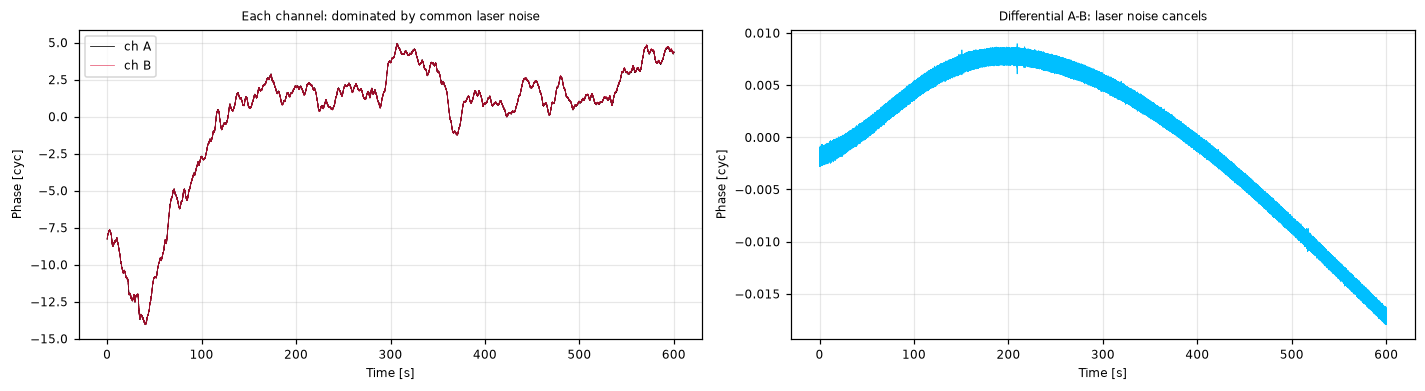

In [4]:
example_file = os.path.join(FM1_DIR,
    "FM1Day06_AnchoredAirOPD_EDUbase_R1_20260609_135823.zip")

data = load_phasemeter(example_file)
print(f"name      : {data.name}")
print(f"fs        : {data.fs:.4f} Hz")
print(f"duration  : {data.duration:.1f} s  ({data.t.size} samples)")
print(f"channels  : {data.nchan}")

a = data.channel_cycles[0]
b = data.channel_cycles[1]

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(data.t, a - a.mean(), lw=0.5, label="ch A")
ax[0].plot(data.t, b - b.mean(), lw=0.5, label="ch B", alpha=0.7)
ax[0].set(xlabel="Time [s]", ylabel="Phase [cyc]",
          title="Each channel: dominated by common laser noise")
ax[0].legend()

ax[1].plot(data.t, (a - b) - (a - b).mean(), lw=0.5, color="C2")
ax[1].set(xlabel="Time [s]", ylabel="Phase [cyc]",
          title="Differential A-B: laser noise cancels")
fig.tight_layout()

print(f"\nstd(A)     = {np.std(a):.4e} cyc")
print(f"std(B)     = {np.std(b):.4e} cyc")
print(f"std(A-B)   = {np.std(a-b):.4e} cyc  "
      f"-> common-mode rejection ~ {np.std(a)/np.std(a-b):.0f}x")


<a id="differential"></a>
## 3. Why the *differential* phase

Both channels share the same laser, so each individual phase is dominated by the
laser's frequency noise coupling through its (large, ~cm-scale) absolute arm
imbalance — this is the huge, slow wander seen above. Their **difference**
$\varphi = \varphi_A - \varphi_B$ cancels this common contribution
(~$10^{3}$&times; rejection here) and leaves the **residual differential OPD** —
exactly the quantity of interest for a nominally balanced two-beam
interferometer.

The injected $f_\mathrm{mod}$ tone is common to both channels too, so it is
*also* strongly rejected in the difference: what survives is the tone amplitude
due to the **residual** OPD mismatch. The spectra below make this concrete — the
tone is huge in A and B, and reduced (but cleanly measurable) in A&minus;B.

`het_ifo_opd` therefore uses the differential phase as the observable, while still
reporting each channel's absolute OPD as a diagnostic.

   A: tone amplitude = 2.873e-02 cyc  ->  OPD =   45.820 mm
   B: tone amplitude = 2.941e-02 cyc  ->  OPD =   46.892 mm
 A-B: tone amplitude = 6.721e-04 cyc  ->  OPD =    1.072 mm


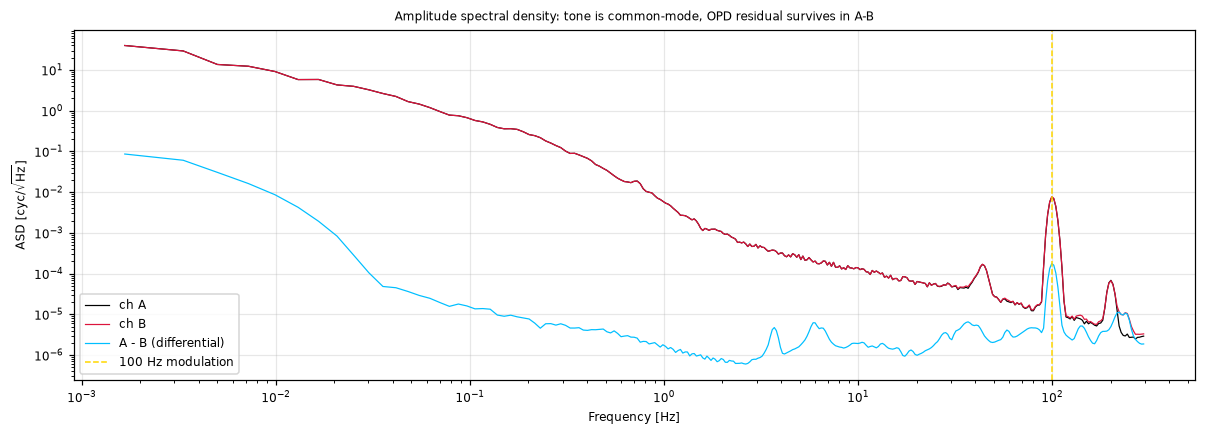

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
for sig, lab, c in [(a, "ch A", "C0"), (b, "ch B", "C1"),
                    (a - b, "A - B (differential)", "C2")]:
    s = compute_spectrum(sig - np.mean(sig), data.fs, win="kaiser", olap="default")
    ax.loglog(s.f, s.asd, lw=0.8, color=c, label=lab)
ax.axvline(100.0, color="C3", ls="--", lw=1, label="100 Hz modulation")
ax.set(xlabel="Frequency [Hz]", ylabel=r"ASD [cyc/$\sqrt{\mathrm{Hz}}$]",
       title="Amplitude spectral density: tone is common-mode, OPD residual survives in A-B")
ax.legend()
fig.tight_layout()

# Quantify the 100 Hz tone in each, and the residual OPD it implies.
for sig, lab in [(a, "A"), (b, "B"), (a - b, "A-B")]:
    amp = single_bin_amplitude(sig - np.mean(sig), data.fs, 100.0)
    opd = phase_cycles_to_opd(amp, cfg.freq_dev_peak)
    print(f"{lab:>4}: tone amplitude = {amp:.3e} cyc  ->  OPD = {opd*1e3:8.3f} mm")


<a id="estimator"></a>
## 4. The estimator

### 4.1 Primary: least-squares lock-in (synchronous detection)

We model the differential phase as the tone plus nuisances and solve a single
linear least-squares problem:

$$
\varphi(t) \;=\; \underbrace{\sum_{k=1}^{K}\big[a_k\cos(2\pi k f_0 t) + b_k\sin(2\pi k f_0 t)\big]}_{\text{fundamental + harmonics}}
\;+\; \underbrace{\sum_{p=0}^{P} c_p\,t^{p}}_{\text{slow drift}} \;+\; n(t).
$$

The OPD signal is the **fundamental** amplitude $A_\varphi=\sqrt{a_1^2+b_1^2}$.
The harmonics absorb any drive/actuator distortion, and the polynomial absorbs
the residual slow drift, so neither biases the fundamental. For a single tone of
known frequency in (locally white) noise this least-squares amplitude is the
**maximum-likelihood / minimum-variance unbiased estimator** — i.e. optimal.

The tone frequency $f_0$ is taken from the known drive (100 Hz on Day06, 95 Hz
on Day09) and refined on a fine periodogram grid to absorb any drive/digitizer
clock offset.

### 4.2 Independent cross-check: LPSD single bin

As an independent check we also read the tone amplitude from a windowed power
spectrum (`speckit`): for a coherent sinusoid the one-sided power-spectrum value
at the tone equals $A^2/2$, so $A=\sqrt{2\,\mathrm{PS}}$. Agreement between the
lock-in and the spectral estimate is reported as a quality metric.

### 4.3 Uncertainty

* **Coherent (statistical):** with integration time $T$ and one-sided noise PSD
  $S_n(f_0)$, the amplitude standard deviation is
  $\sigma_A = \sqrt{S_n(f_0)/T}$, equal to the Cramér–Rao bound
  $\sigma\sqrt{2/N}$ for white noise. $S_n$ is measured **on the lock-in
  residual** (tone removed), so the tone's spectral leakage cannot inflate it.
* **Empirical (drift):** the scatter of the per-segment estimates, which
  additionally captures genuine slow OPD non-stationarity.

The cell below reproduces the lock-in *by hand* on the example file to show that
it is nothing more than a linear fit, and that it agrees with the package.

In [6]:
# --- Lock-in "by hand": one linear least-squares solve ---------------------
phi = (a - b) - np.mean(a - b)
fs = data.fs
t = np.arange(phi.size) / fs
f0 = 100.0

K, P = 3, 3          # harmonics, polynomial order
cols = []
for k in range(1, K + 1):
    cols += [np.cos(2 * np.pi * k * f0 * t), np.sin(2 * np.pi * k * f0 * t)]
cols += [t ** p for p in range(P + 1)]
M = np.vstack(cols).T
coef, *_ = np.linalg.lstsq(M, phi, rcond=None)

a1, b1 = coef[0], coef[1]
A_manual = np.hypot(a1, b1)
opd_manual = phase_cycles_to_opd(A_manual, cfg.freq_dev_peak)
print(f"by-hand lock-in : A = {A_manual:.6e} cyc  ->  OPD = {opd_manual*1e3:.4f} mm")

# --- Same thing via the package -------------------------------------------
lk = lockin_amplitude(phi, fs, f0)
sp = single_bin_amplitude(phi, fs, f0)
print(f"package lock-in : A = {lk.amplitude:.6e} cyc  ->  OPD = "
      f"{phase_cycles_to_opd(lk.amplitude, cfg.freq_dev_peak)*1e3:.4f} mm")
print(f"spectral cross  : A = {sp:.6e} cyc  (agreement "
      f"{abs(lk.amplitude-sp)/lk.amplitude:.1e})")
print(f"coherent sigma_A: {lk.amp_unc_coherent:.2e} cyc  -> "
      f"{phase_cycles_to_opd(lk.amp_unc_coherent, cfg.freq_dev_peak)*1e6:.3f} um")


by-hand lock-in : A = 6.720937e-04 cyc  ->  OPD = 1.0717 mm
package lock-in : A = 6.720937e-04 cyc  ->  OPD = 1.0717 mm
spectral cross  : A = 6.720877e-04 cyc  (agreement 9.0e-06)
coherent sigma_A: 1.87e-07 cyc  -> 0.299 um


<a id="single"></a>
## 5. Worked single-file example

`estimate_opd` packages the whole chain into one call and returns an
`OPDResult` with the headline OPD, both uncertainties, and a set of quality
diagnostics. The 3-panel diagnostic figure shows:

1. the differential-phase ASD with the tone marked,
2. the **phase-folded** tone (synchronous averaging over all cycles, which makes
   even a weak tone visible above the broadband noise), and
3. the **per-segment OPD**, revealing any slow drift across the record.

Acquisition : FM1Day06_AnchoredAirOPD_EDUbase_R1_20260609_135823
Observable  : ch1-ch2
Tone        : 100.0000 Hz   (SNR 4.97e+05)
--------------------------------------------------------
Residual OPD = 1.0717 mm
   +/-   0.30 um  (coherent, statistical)
   +/-   6.40 um  (per-segment drift)
--------------------------------------------------------
lock-in amplitude  : 6.7209e-04 cyc
spectral amplitude : 6.7209e-04 cyc
method agreement   : 9.01e-06
2nd-harmonic ratio : 1.29e-02
equivalent delay   : 3.575 ps
per-channel OPD    : ch1=45.8 mm, ch2=46.9 mm


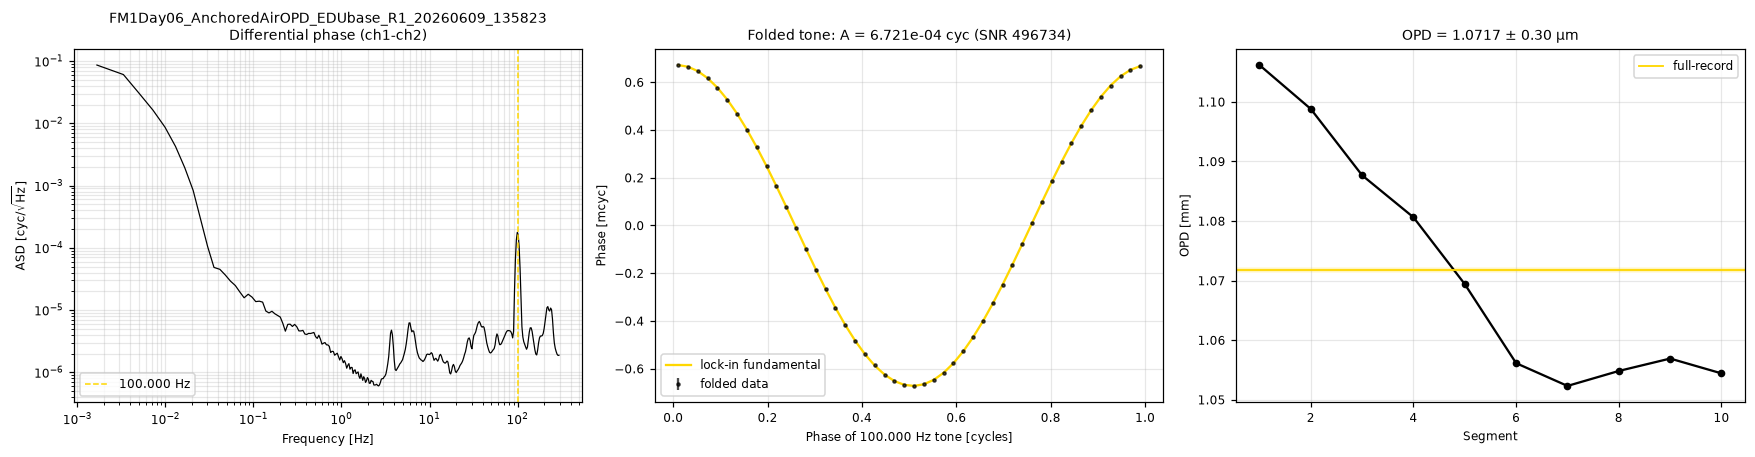

In [7]:
r = estimate_opd(example_file, mod_freq=100.0)

print(f"Acquisition : {r.name}")
print(f"Observable  : {r.observable}")
print(f"Tone        : {r.tone_freq:.4f} Hz   (SNR {r.tone_snr:.3g})")
print("-" * 56)
print(f"Residual OPD = {r.opd*1e3:.4f} mm")
print(f"   +/- {r.opd_unc*1e6:6.2f} um  (coherent, statistical)")
print(f"   +/- {r.opd_unc_empirical*1e6:6.2f} um  (per-segment drift)")
print("-" * 56)
print(f"lock-in amplitude  : {r.amp_cycles:.4e} cyc")
print(f"spectral amplitude : {r.amp_cycles_spectral:.4e} cyc")
print(f"method agreement   : {r.method_agreement:.2e}")
print(f"2nd-harmonic ratio : {r.harmonic_ratio:.2e}")
print(f"equivalent delay   : {r.delay*1e12:.3f} ps")
print(f"per-channel OPD    : "
      + ", ".join(f"{k}={v*1e3:.1f} mm" for k, v in r.channel_opds.items()))

fig = plot_diagnostics(r, data=data)
plt.show()


<a id="full"></a>
## 6. Full FM1 analysis

We now run every FM1 acquisition. Two modulation frequencies were used:
**Day06 = 100 Hz**, **Day09 = 95 Hz** (the peak frequency deviation, and hence
the OPD conversion, is the same for both since the actuator gain is flat). A
small resolver assigns the right frequency per file by its name.

> Note: this loads ~16 files of ~600 s each, so the cell takes a couple of
> minutes.

In [ ]:
def fm1_freq(path):
    name = os.path.basename(path)
    if "Day09" in name:
        return 95.0
    if "Day06" in name:
        return 100.0
    return None

dataset = estimate_opd_dataset(FM1_DIR, config=cfg, freq_resolver=fm1_freq)
df = dataset.to_dataframe().sort_values("name").reset_index(drop=True)

# Derive experimental categories from the filename for grouping/discussion.
df["day"] = np.where(df["name"].str.contains("Day09"), "Day09", "Day06")
df["anchoring"] = np.select(
    [df["name"].str.contains("Unanchored"),
     df["name"].str.contains("Anchored"),
     df["name"].str.contains("Released")],
    ["unanchored", "anchored", "released"], default="other")
df["medium"] = np.where(df["name"].str.contains("Vacuum"), "vacuum", "air")
df["rep"] = np.where(df["name"].str.contains("_R2"), "R2", "R1")

cols = ["name", "day", "anchoring", "medium", "rep", "OPD_mm", "OPD_unc_um",
        "OPD_unc_emp_um", "tone_freq_Hz", "tone_snr", "method_agreement",
        "harmonic_ratio"]
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
df[cols]


In [ ]:
fig = plot_dataset_summary(dataset)
plt.show()


In [ ]:
# The two uncertainty channels tell different stories: the *coherent* sigma is
# the statistical measurement floor, while the *empirical* (per-segment) sigma
# reflects genuine mechanical OPD drift. Compare them by configuration.
g = (df.groupby("anchoring")
       .agg(n=("OPD_mm", "size"),
            OPD_mm_mean=("OPD_mm", "mean"),
            coherent_um=("OPD_unc_um", "median"),
            drift_um=("OPD_unc_emp_um", "median"),
            SNR_median=("tone_snr", "median"),
            agree_median=("method_agreement", "median"))
       .round(3))
print(g, "\n")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"anchored": "C0", "unanchored": "C1", "released": "C2"}
for cfgname, sub in df.groupby("anchoring"):
    ax.scatter(sub["OPD_unc_um"], sub["OPD_unc_emp_um"],
               s=40, color=colors.get(cfgname, "C3"), label=cfgname, alpha=0.8)
lims = [1e-1, 1e3]
ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5, label="equal")
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims,
       xlabel="coherent (statistical) sigma [um]",
       ylabel="empirical (drift) sigma [um]",
       title="Drift, not measurement noise, limits the unanchored / released runs")
ax.legend()
fig.tight_layout()
plt.show()


In [ ]:
# Repeatability: pair the two runs (R1/R2) of each configuration.
df["config"] = (df["day"] + " " + df["anchoring"] + " " + df["medium"]
                + " " + df["name"].str.extract(r"(NOSHIMS|SHIMMED)").fillna("")[0]
                + np.where(df["name"].str.contains("FLIGHTTORQUED"), " TORQUED", ""))
pivot = df.pivot_table(index="config", columns="rep", values="OPD_mm")
pivot["|R1-R2| [um]"] = (pivot.get("R1") - pivot.get("R2")).abs() * 1e3
pivot.round(4)


<a id="discussion"></a>
## 7. Discussion of results

The residual differential OPD across the FM1 acquisitions lies in the
**~0.1–1.4 mm** range. The headline numbers and their quality flags support a
few clear conclusions (see the tables/plots above):

**1. The measurement itself is not the limitation.** On the anchored
configurations the modulation tone sits enormously above the noise (SNR
$\sim10^{5}$–$10^{6}$), the lock-in and spectral estimates agree to
$\lesssim10^{-3}$, and the *coherent* (statistical) uncertainty is **sub-µm**.
The frequency-modulation method delivers an extremely precise OPD readout.

**2. Mechanical stability dominates the error budget.** The
coherent-vs-empirical scatter plot shows the *empirical* (per-segment drift)
uncertainty is far larger than the statistical one in every configuration, and
grows from a few µm (anchored) to tens–hundreds of µm (unanchored / released).
In other words, what limits these acquisitions is the OPD physically *moving*
during the 600 s record — visible directly in the per-segment panel of the
diagnostic plots — not photon/readout noise. This is the expected behaviour: anchoring the optic
holds the OPD steady; unanchored / freshly-released assemblies relax and drift.

**3. Repeatability tracks stability, and is best in vacuum.** The standout is
**anchored-vacuum**, whose two runs agree to ~9 µm — by far the most repeatable
configuration. The unanchored / released cases differ between runs by hundreds
of µm, consistent with their large drift. Interestingly **anchored-air** also
shows a large run-to-run difference (~0.4 mm), i.e. anchoring alone is not
sufficient in air; removing the air (vacuum) is what makes the OPD both stable
*and* repeatable. (All run-to-run differences here are configuration/stability
effects, far above the sub-µm statistical precision.)

**4. The quality diagnostics behave as designed.** Low tone SNR, poor
lock-in/spectral agreement, and an elevated 2nd-harmonic ratio all co-occur on
the weak / drifting acquisitions, flagging exactly the records whose single
"OPD number" should be read together with the per-segment drift rather than in
isolation.

**Practical takeaway:** trust the anchored numbers as precise OPD values; for
the unanchored / released configurations report the per-segment OPD *and* its
drift, since the residual OPD is genuinely time-varying there.

<a id="conclusions"></a>
## 8. Conclusions

* A known single-tone **laser-frequency modulation** turns the interferometer
  into a self-calibrating OPD sensor: the residual OPD is
  $\mathrm{OPD} = A_\varphi\, c / \delta\nu_\mathrm{pk}$, read from the amplitude
  of the tone in the **differential** phase — wavelength-independent and immune
  to the large DC interferometer phase.
* A **least-squares lock-in** gives the optimal (maximum-likelihood) amplitude,
  cross-checked by an independent LPSD single-bin estimate; the coherent
  uncertainty equals the Cramér–Rao bound and is verified by the synthetic
  Monte-Carlo tests in `tests/`.
* Applied to FM1, the method measures residual OPDs of ~0.1–1.4 mm with sub-µm
  *statistical* precision; the dominant uncertainty for unanchored / released
  configurations is **real mechanical drift**, which the per-segment diagnostics
  expose and quantify.

To reproduce the whole analysis outside this notebook:

```bash
python scripts/analyze_fm1.py FM1 results
# or
python -m het_ifo_opd FM1/ --freq-map Day09=95 Day06=100 --out results --plots
```